# Depth Map Test Evaluation

Apply the best alpha/beta from validation and evaluate **any** predicted depth map against a ground truth.

**Metrics reported:** AbsRel, RMSE, SILog, R², δ<1.25, δ<1.25², δ<1.25³, RMSE_log, Sq_rel

In [1]:
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

## 1. Configuration — Edit these cells

### 1a. Alpha / Beta source

Pick **one** of the two options below.

In [48]:
# ── Option A: load from a JSON file produced by evaluate_alpha_beta.py ──
# Set AB_JSON to None to skip and use Option B instead.

DATA_ROOT = Path("/nfs/hpc/share/sanchej7/Computer_Vision/Data/full_trunk")

AB_JSON = DATA_ROOT / "alpha_beta_metric.json"   # change to alpha_beta.json for relative mode

# Which granularity to use: "global", "per_shot", or "per_tree"
# For per_shot / per_tree you also need to set SHOT_KEY / TREE_KEY below.
GRANULARITY = "per_shot"   # "global" | "per_shot" | "per_tree"

SHOT_KEY = "shot03"        # used only when GRANULARITY == "per_shot"
TREE_KEY = "lpy_envy_00052"  # used only when GRANULARITY == "per_tree"

In [47]:
# ── Option B: hard-code alpha and beta directly ──
# These are ignored when AB_JSON is not None.

MANUAL_ALPHA = 0.0257
MANUAL_BETA  = 1.575

### 1b. Depth map paths

In [52]:
# Path to the PREDICTED depth map you want to test (.npy, float32/float64)
PRED_PATH = Path("/nfs/hpc/share/sanchej7/Computer_Vision/Data/trunk_spurs/"
                 "depth_anythingv3_metric/bark_brown/lpy_envy_00003/lpy_envy_00003_shot03.npy")

# Path to the ground-truth depth map (.npy, in metres for metric mode)
GT_PATH = Path("/nfs/hpc/share/sanchej7/Computer_Vision/Data/trunk_spurs/"
               "depth/bark_brown/lpy_envy_00003/lpy_envy_00003_shot03.npy")

# Optional: trunk-only mask PNG (set to None to use all valid pixels)
MASK_PATH = None
# Example:
# MASK_PATH = Path("/nfs/hpc/share/sanchej7/Computer_Vision/Data/full_trunk/"
#                  "mask/bark_brown/lpy_envy_00052/lpy_envy_00052_shot01_c_tree_0001.png")

# Max GT depth to treat as valid (15.0 m for metric, 1e6 for relative)
MAX_GT = 15.0

## 2. Helpers (same logic as evaluate_alpha_beta.py)

In [ ]:
def resolve_alpha_beta(ab_json, granularity, shot_key, tree_key, manual_alpha, manual_beta):
    """Return (alpha, beta) from JSON or manual override."""
    if ab_json is None:
        return manual_alpha, manual_beta

    with open(ab_json) as f:
        params = json.load(f)

    if granularity == "global":
        p = params["global"]
    elif granularity == "per_shot":
        p = params["per_shot"].get(shot_key, params["global"])
        if shot_key not in params["per_shot"]:
            print(f"[warn] shot '{shot_key}' not found — falling back to global.")
    elif granularity == "per_tree":
        p = params["per_tree"].get(tree_key, params["global"])
        if tree_key not in params["per_tree"]:
            print(f"[warn] tree '{tree_key}' not found — falling back to global.")
    else:
        raise ValueError(f"Unknown granularity: {granularity}")

    return p["alpha"], p["beta"]


def load_and_align(gt_path, pred_path, max_gt, mask_path=None):
    """Load GT and predicted depth, apply mask, align to common resolution.
    Returns (gt_2d, pred_2d, valid_mask_2d).
    """
    gt   = np.load(gt_path).astype(np.float64)
    pred = np.load(pred_path).astype(np.float64)

    # Mask invalid GT at full resolution
    invalid = ~((gt > 0) & (gt <= max_gt) & np.isfinite(gt))
    gt[invalid] = np.nan

    # Apply trunk mask (full GT resolution)
    if mask_path is not None and Path(mask_path).exists():
        mask_img = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        trunk = mask_img > 0
        gt[~trunk] = np.nan

    # Downsample GT to pred resolution if needed
    if gt.shape != pred.shape:
        gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_AREA)

    valid = (np.isfinite(gt) & (gt > 0) & (gt < max_gt) &
             np.isfinite(pred) & (pred > 0))

    print(f"  GT   shape : {gt.shape}")
    print(f"  Pred shape : {pred.shape}")
    print(f"  Valid pixels: {valid.sum():,} / {valid.size:,} "
          f"({100*valid.mean():.1f}%)")

    return gt, pred, valid


def apply_calibration(pred, alpha, beta):
    return alpha * pred + beta


def compute_metrics(gt_flat, pred_flat):
    """Compute all depth metrics on flat valid-pixel arrays."""
    pred_flat = np.clip(pred_flat, 1e-6, None)
    gt_flat   = np.clip(gt_flat,   1e-6, None)

    thresh    = np.maximum(gt_flat / pred_flat, pred_flat / gt_flat)
    a1        = (thresh < 1.25      ).mean()
    a2        = (thresh < 1.25 ** 2 ).mean()
    a3        = (thresh < 1.25 ** 3 ).mean()

    abs_rel   = np.mean(np.abs(gt_flat - pred_flat) / gt_flat)
    sq_rel    = np.mean(((gt_flat - pred_flat) ** 2) / gt_flat)
    rmse      = np.sqrt(np.mean((gt_flat - pred_flat) ** 2))

    log_diff  = np.log(pred_flat) - np.log(gt_flat)
    rmse_log  = np.sqrt(np.mean(log_diff ** 2))
    silog     = np.sqrt(np.mean(log_diff ** 2) - np.mean(log_diff) ** 2) * 100

    ss_res    = np.sum((gt_flat - pred_flat) ** 2)
    ss_tot    = np.sum((gt_flat - gt_flat.mean()) ** 2)
    r2        = 1.0 - ss_res / max(ss_tot, 1e-12)

    return dict(abs_rel=abs_rel, rmse=rmse, silog=silog, r2=r2,
                a1=a1, a2=a2, a3=a3, rmse_log=rmse_log, sq_rel=sq_rel)

## 3. Load data & resolve alpha / beta

In [30]:
alpha, beta = resolve_alpha_beta(
    AB_JSON, GRANULARITY, SHOT_KEY, TREE_KEY, MANUAL_ALPHA, MANUAL_BETA
)
print(f"Using  alpha = {alpha:.6f},  beta = {beta:.6f}")
print(f"Source: {'JSON – ' + GRANULARITY if AB_JSON else 'manual'}")

Using  alpha = 0.215146,  beta = -2.003189
Source: JSON – per_shot


In [42]:

DATA_ROOT2 = Path("/nfs/hpc/share/sanchej7/Computer_Vision/Data/trunk_spurs")

MASK_PATH = DATA_ROOT2 / "mask/bark_brown/lpy_envy_00003/lpy_envy_00003_shot03_c_tree_0003.png" 

gt, pred_raw, valid = load_and_align(GT_PATH, PRED_PATH, MAX_GT, MASK_PATH)

  GT   shape : (280, 504)
  Pred shape : (280, 504)
  Valid pixels: 5,422 / 141,120 (3.8%)


## 4. Apply calibration & compute metrics

In [43]:
pred_cal = apply_calibration(pred_raw, alpha, beta)

# Valid after calibration (pred must also be positive)
valid_cal = valid & (pred_cal > 0)

gt_v      = gt[valid_cal]
raw_v     = pred_raw[valid_cal]
cal_v     = pred_cal[valid_cal]

m_raw = compute_metrics(gt_v, raw_v)
m_cal = compute_metrics(gt_v, cal_v)

print(f"\nValid pixels used for metrics: {valid_cal.sum():,}")


Valid pixels used for metrics: 5,422


## 5. Results table

In [44]:
metrics_order = [
    ("AbsRel",   "abs_rel",  "↓"),
    ("RMSE",     "rmse",     "↓"),
    ("SILog",    "silog",    "↓"),
    ("RMSE_log", "rmse_log", "↓"),
    ("Sq_rel",   "sq_rel",   "↓"),
    ("R²",       "r2",       "↑"),
    ("δ<1.25",   "a1",       "↑"),
    ("δ<1.25²",  "a2",       "↑"),
    ("δ<1.25³",  "a3",       "↑"),
]

header = f"{'Metric':<12} {'Dir':>3}  {'Uncalibrated':>14}  {'Calibrated':>14}  {'Δ (cal-raw)':>14}"
sep    = "-" * len(header)
print(header)
print(sep)

for label, key, direction in metrics_order:
    raw_v_ = m_raw[key]
    cal_v_ = m_cal[key]
    delta  = cal_v_ - raw_v_
    # Mark improvement in green-ish notation
    if direction == "↓":
        improved = delta < 0
    else:
        improved = delta > 0
    flag = " ✓" if improved else "  "
    print(f"{label:<12} {direction:>3}  {raw_v_:>14.4f}  {cal_v_:>14.4f}  {delta:>+14.4f}{flag}")

print(sep)
print(f"alpha={alpha:.6f}  beta={beta:.6f}  |  valid pixels: {valid_cal.sum():,}")

Metric       Dir    Uncalibrated      Calibrated     Δ (cal-raw)
----------------------------------------------------------------
AbsRel         ↓          4.8781          0.7328         -4.1453 ✓
RMSE           ↓          9.7647          1.5374         -8.2273 ✓
SILog          ↓         14.2355         17.8156         +3.5801  
RMSE_log       ↓          1.7665          1.3479         -0.4186 ✓
Sq_rel         ↓         47.8709          1.1203        -46.7506 ✓
R²             ↑      -1274.2367        -30.6131      +1243.6236 ✓
δ<1.25         ↑          0.0000          0.0000         +0.0000  
δ<1.25²        ↑          0.0000          0.0000         +0.0000  
δ<1.25³        ↑          0.0000          0.0042         +0.0042 ✓
----------------------------------------------------------------
alpha=0.215146  beta=-2.003189  |  valid pixels: 5,422


## 6. Visualizations

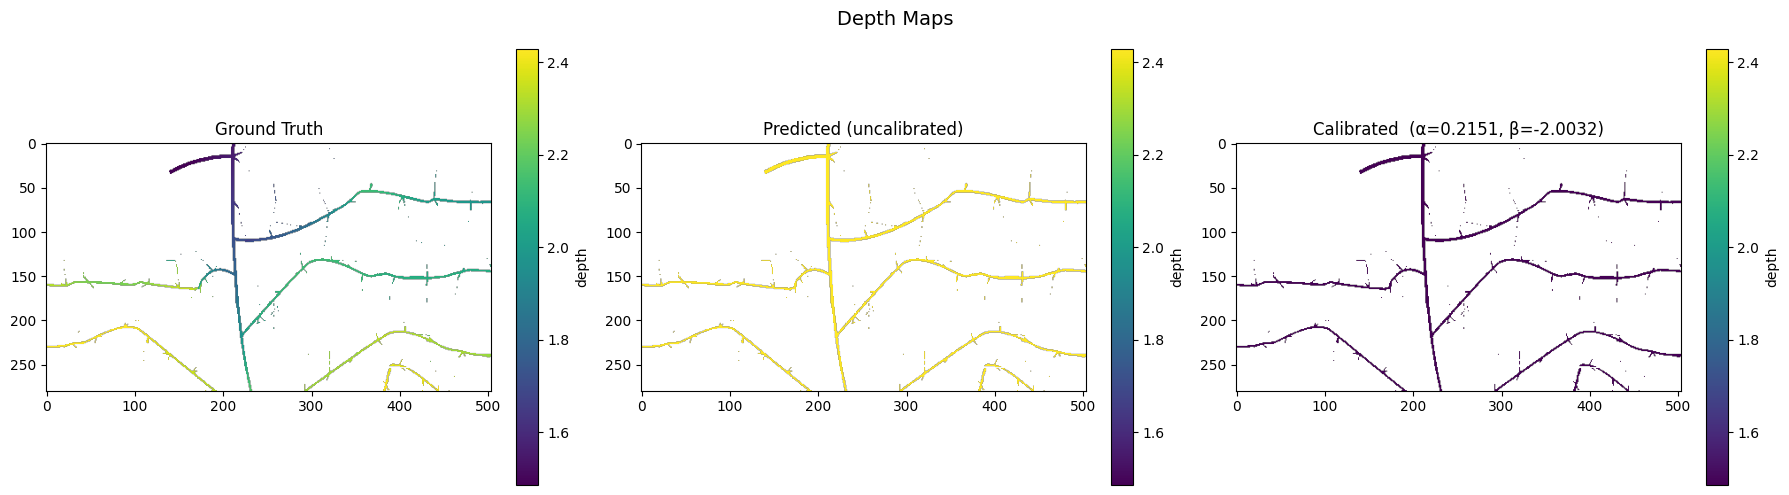

In [45]:
# ── 6a. Side-by-side depth maps ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

gt_disp   = np.where(valid_cal, gt,       np.nan)
raw_disp  = np.where(valid_cal, pred_raw, np.nan)
cal_disp  = np.where(valid_cal, pred_cal, np.nan)

vmin = np.nanpercentile(gt_disp, 2)
vmax = np.nanpercentile(gt_disp, 98)

im0 = axes[0].imshow(gt_disp,  cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground Truth")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="depth")

im1 = axes[1].imshow(raw_disp, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Predicted (uncalibrated)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="depth")

im2 = axes[2].imshow(cal_disp, cmap="viridis", vmin=vmin, vmax=vmax)
axes[2].set_title(f"Calibrated  (α={alpha:.4f}, β={beta:.4f})")
plt.colorbar(im2, ax=axes[2], fraction=0.046, label="depth")

fig.suptitle("Depth Maps", fontsize=14)
fig.tight_layout()
plt.show()

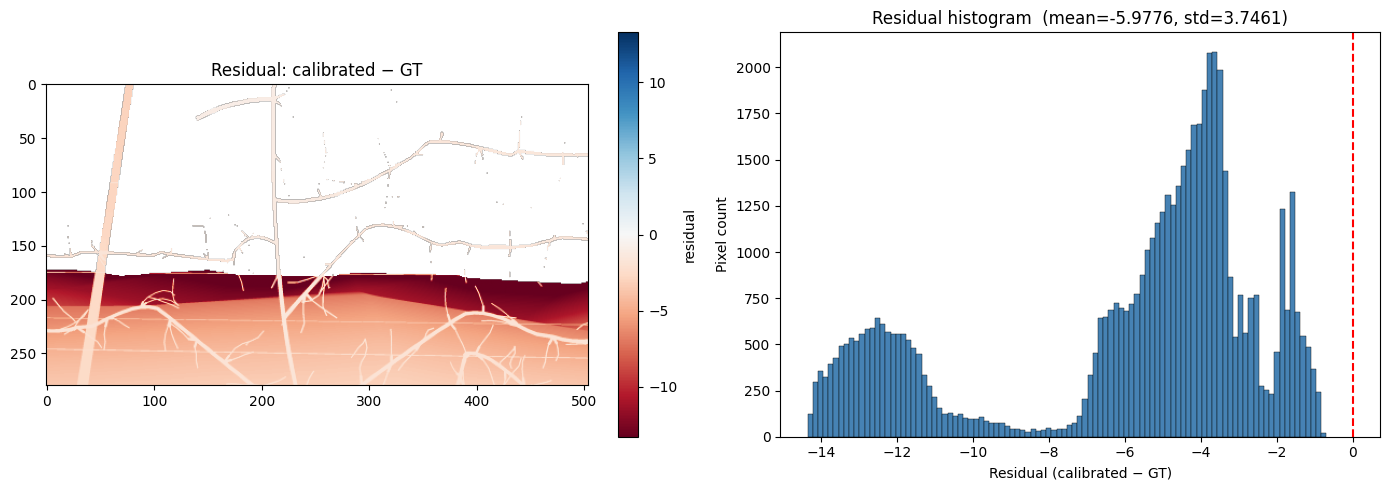

In [37]:
# ── 6b. Residual map (calibrated - GT) ───────────────────────────────
resid = np.where(valid_cal, pred_cal - gt, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vr = np.nanpercentile(np.abs(resid[valid_cal]), 95)
im = axes[0].imshow(resid, cmap="RdBu", vmin=-vr, vmax=vr)
axes[0].set_title("Residual: calibrated − GT")
plt.colorbar(im, ax=axes[0], fraction=0.046, label="residual")

resid_flat = resid[valid_cal]
axes[1].hist(resid_flat, bins=100, color="steelblue", edgecolor="k", linewidth=0.3)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (calibrated − GT)")
axes[1].set_ylabel("Pixel count")
mean_r = resid_flat.mean()
std_r  = resid_flat.std()
axes[1].set_title(f"Residual histogram  (mean={mean_r:.4f}, std={std_r:.4f})")

fig.tight_layout()
plt.show()

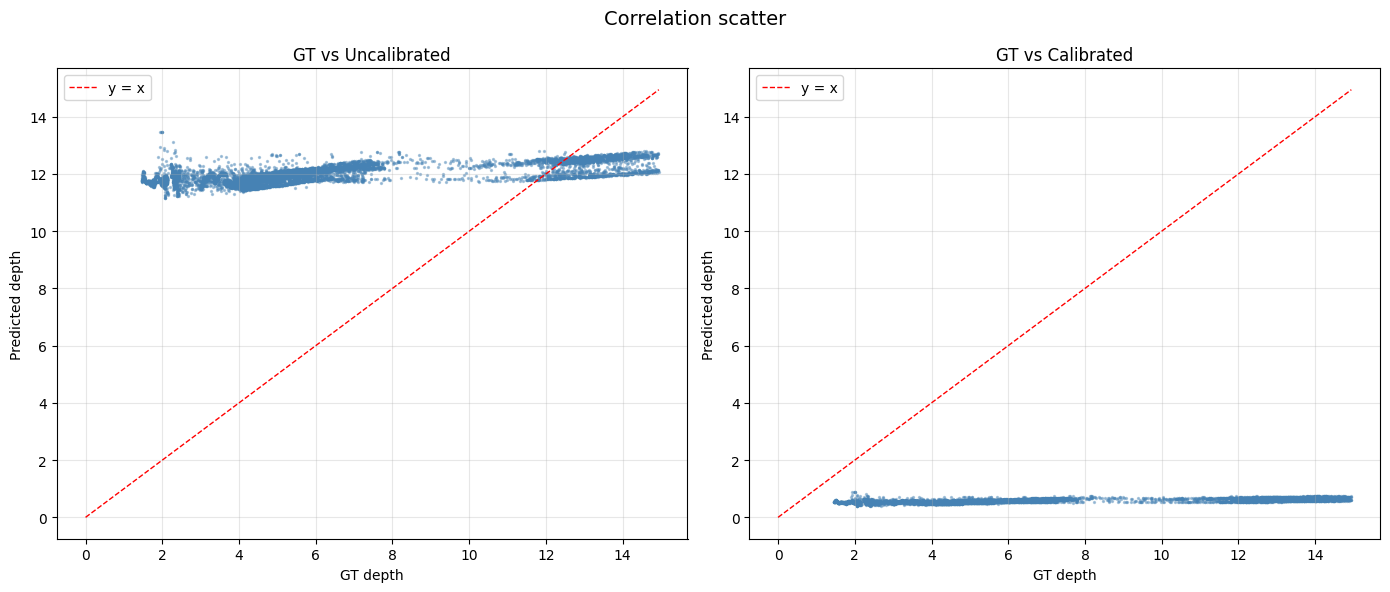

In [38]:
# ── 6c. Scatter: GT vs predicted (both raw and calibrated) ───────────
MAX_SCATTER = 8000
idx = np.random.default_rng(0).choice(len(gt_v), min(MAX_SCATTER, len(gt_v)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred_v_, title in [
    (axes[0], raw_v[idx], "GT vs Uncalibrated"),
    (axes[1], cal_v[idx], "GT vs Calibrated"),
]:
    ax.scatter(gt_v[idx], pred_v_, s=2, alpha=0.4, c="steelblue")
    lim = max(gt_v[idx].max(), pred_v_.max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="y = x")
    ax.set_xlabel("GT depth")
    ax.set_ylabel("Predicted depth")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Correlation scatter", fontsize=14)
fig.tight_layout()
plt.show()

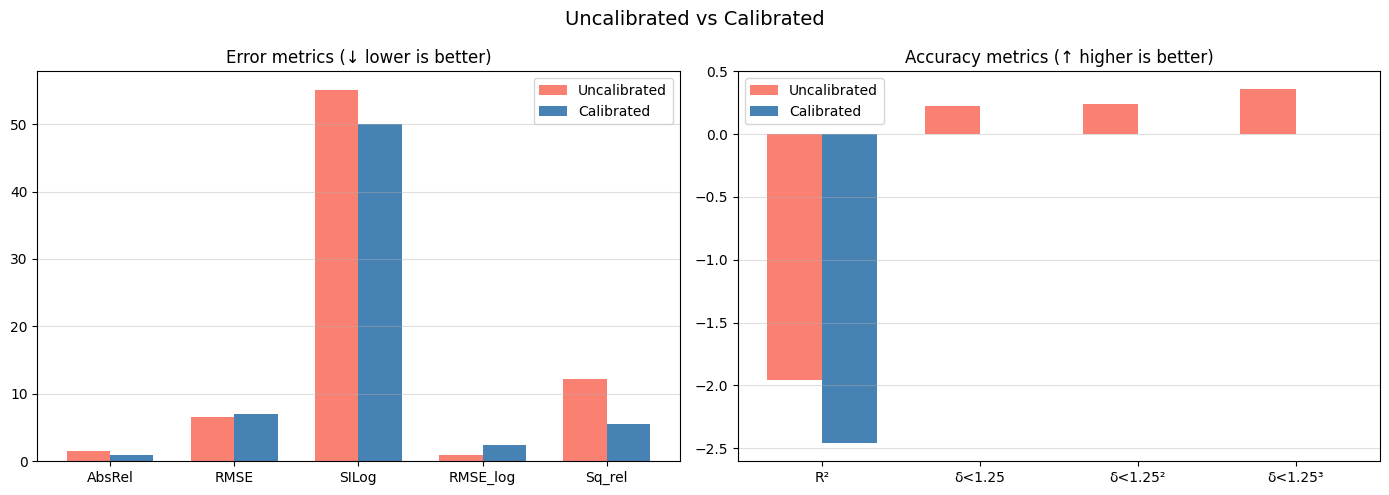

In [39]:
# ── 6d. Metrics bar chart ─────────────────────────────────────────────
error_metrics  = ["AbsRel", "RMSE", "SILog", "RMSE_log", "Sq_rel"]
error_keys     = ["abs_rel", "rmse", "silog", "rmse_log", "sq_rel"]
acc_metrics    = ["R²", "δ<1.25", "δ<1.25²", "δ<1.25³"]
acc_keys       = ["r2", "a1", "a2", "a3"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_err = np.arange(len(error_metrics))
w = 0.35
axes[0].bar(x_err - w/2, [m_raw[k] for k in error_keys], w, label="Uncalibrated", color="salmon")
axes[0].bar(x_err + w/2, [m_cal[k] for k in error_keys], w, label="Calibrated",   color="steelblue")
axes[0].set_xticks(x_err)
axes[0].set_xticklabels(error_metrics)
axes[0].set_title("Error metrics (↓ lower is better)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.4)

x_acc = np.arange(len(acc_metrics))
axes[1].bar(x_acc - w/2, [m_raw[k] for k in acc_keys], w, label="Uncalibrated", color="salmon")
axes[1].bar(x_acc + w/2, [m_cal[k] for k in acc_keys], w, label="Calibrated",   color="steelblue")
axes[1].set_xticks(x_acc)
axes[1].set_xticklabels(acc_metrics)
axes[1].set_title("Accuracy metrics (↑ higher is better)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.4)

fig.suptitle("Uncalibrated vs Calibrated", fontsize=14)
fig.tight_layout()
plt.show()

## 7. (Optional) Try multiple alpha/beta pairs & compare

Useful if you want to compare global vs per-shot vs per-tree—or test vs validation alpha/beta—on the same image.

In [ ]:
# Define the pairs you want to compare (name → (alpha, beta))
# Set to {} to skip this cell.
COMPARE_PAIRS = {}  # Example:
# COMPARE_PAIRS = {
#     "Global":     (0.0257, 1.575),
#     "Per-shot01": (0.0193, 1.863),
#     "Per-shot02": (-0.0506, 3.015),
# }

if COMPARE_PAIRS:
    header2 = (f"{'Name':<15} {'alpha':>10} {'beta':>10}  {'AbsRel':>9} {'RMSE':>9} "
               f"{'SILog':>9} {'R²':>9} {'δ<1.25':>9}")
    print(header2)
    print("-" * len(header2))
    for name, (a, b) in COMPARE_PAIRS.items():
        pc = apply_calibration(pred_raw, a, b)
        v  = valid & (pc > 0)
        m  = compute_metrics(gt[v], pc[v])
        print(f"{name:<15} {a:>10.6f} {b:>10.6f}  "
              f"{m['abs_rel']:>9.4f} {m['rmse']:>9.4f} "
              f"{m['silog']:>9.2f} {m['r2']:>9.4f} {m['a1']:>9.4f}")
else:
    print("COMPARE_PAIRS is empty — nothing to compare.")

## 8. (Optional) Scan a directory of depth maps

Point `SCAN_PRED_DIR` and `SCAN_GT_DIR` at directories of `.npy` files with matching names.

In [ ]:
SCAN_PRED_DIR = None   # e.g. Path(".../depth_anythingv3_metric/bark_brown/lpy_envy_00052")
SCAN_GT_DIR   = None   # e.g. Path(".../depth/bark_brown/lpy_envy_00052")
SCAN_MASK_DIR = None   # optional

if SCAN_PRED_DIR and SCAN_GT_DIR:
    from collections import defaultdict

    pred_files = sorted(Path(SCAN_PRED_DIR).glob("*.npy"))
    per_image  = []

    for pf in pred_files:
        gf = Path(SCAN_GT_DIR) / pf.name
        if not gf.exists():
            continue

        mask_f = None
        if SCAN_MASK_DIR:
            candidate = Path(SCAN_MASK_DIR) / (pf.stem + ".png")
            if candidate.exists():
                mask_f = candidate

        gt_i, pred_i, valid_i = load_and_align(gf, pf, MAX_GT, mask_f)
        pred_cal_i = apply_calibration(pred_i, alpha, beta)
        v = valid_i & (pred_cal_i > 0)
        if v.sum() < 100:
            continue
        m = compute_metrics(gt_i[v], pred_cal_i[v])
        m["stem"] = pf.stem
        per_image.append(m)

    if per_image:
        keys = ["abs_rel", "rmse", "silog", "r2", "a1"]
        print(f"\n{'stem':<40} {'AbsRel':>9} {'RMSE':>9} {'SILog':>9} {'R²':>9} {'δ<1.25':>9}")
        print("-" * 90)
        for m in per_image:
            print(f"{m['stem']:<40} {m['abs_rel']:>9.4f} {m['rmse']:>9.4f} "
                  f"{m['silog']:>9.2f} {m['r2']:>9.4f} {m['a1']:>9.4f}")

        print("-" * 90)
        for k in keys:
            vals = [m[k] for m in per_image]
            print(f"{'MEAN':<40} {np.mean(vals):>9.4f}" if k == keys[0]
                  else f"{'':40} {np.mean(vals):>9.4f}", end="")
        print()
    else:
        print("No valid pairs found in scan directories.")
else:
    print("SCAN_PRED_DIR / SCAN_GT_DIR not set — skipping scan.")